In [19]:
import pandas as pd 
import numpy as np 
from rdkit import Chem
import torch
from torch_geometric.data import Data 
from torch_geometric.loader import DataLoader
import networkx as nx
import matplotlib.pyplot as plt
from transformers import AutoTokenizer


In [4]:
qm8=pd.read_csv("C:\\Users\\Diya\\PBL\\Molecular-Property-Prediction-Using-GNN-and-Transformer\\Dataset\\qm8.csv")
qm9=pd.read_csv("C:\\Users\\Diya\\PBL\\Molecular-Property-Prediction-Using-GNN-and-Transformer\\Dataset\\qm9.csv")

In [5]:
print(qm8.shape)
print(qm9.shape)

(21786, 17)
(133885, 21)


In [6]:
#checking for hidden missing values

empty_smiles = (qm9['smiles'].str.strip() == "").sum()
print(empty_smiles)

0


In [7]:
'''Canonicalizing smilies - since the smiles in both qm8 nd qm9 are
 in different format we have to change it to a standard format so that
 one molecule should not be treated as two  different molecules'''

def canonicalize(smiles):
    return Chem.MolToSmiles(Chem.MolFromSmiles(smiles))

qm8['smiles_new'] = qm8['smiles'].apply(canonicalize)
qm9['smiles_new'] = qm9['smiles'].apply(canonicalize)

In [8]:
#full outter join to merge both the data

df = pd.merge(qm8, qm9, on='smiles_new', how='outer')

In [9]:
df.shape

(133925, 39)

In [10]:
#Removing invalid smiles

def valid_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol is not None
    except:
        return False

df = df[df['smiles_new'].apply(valid_smiles)]
df = df.reset_index(drop=True)

print("Dataset size:", df.shape)

Dataset size: (133925, 39)


In [27]:
#filling NaN VAlues
#smiles_x --> qm8
#smiles_y --> qm9
#smiles_new --> canonical smiles

target_cols = df.columns.drop(['smiles_x','smiles_y','smiles_new'])
df[target_cols] = df[target_cols].apply(pd.to_numeric, errors='coerce')
df[target_cols] = df[target_cols].fillna(0)
targets = df[target_cols].values
print(targets.dtype)

float64


In [28]:
#canonical smiles string to list

smiles_list = df['smiles_new'].tolist()
targets = df[target_cols].values             #.values converts df to array

In [29]:
#for each smiles string s compute its length and storing it in a list

lengths = [len(s) for s in smiles_list]
print(lengths)

[1, 3, 4, 6, 7, 9, 10, 12, 13, 12, 15, 14, 14, 15, 14, 14, 14, 12, 11, 13, 13, 13, 12, 12, 11, 12, 9, 15, 15, 14, 14, 15, 14, 17, 17, 16, 16, 17, 16, 16, 16, 14, 13, 15, 15, 14, 14, 13, 14, 16, 16, 13, 15, 15, 14, 13, 15, 14, 15, 15, 15, 14, 14, 14, 15, 14, 14, 14, 14, 14, 14, 16, 16, 16, 15, 15, 14, 15, 16, 16, 16, 16, 15, 15, 13, 12, 11, 13, 14, 13, 16, 15, 15, 16, 15, 15, 15, 13, 12, 14, 14, 14, 13, 13, 12, 13, 15, 14, 11, 12, 14, 14, 13, 15, 14, 14, 14, 14, 14, 13, 13, 13, 13, 13, 14, 12, 13, 16, 14, 13, 14, 13, 16, 15, 15, 16, 15, 15, 15, 13, 12, 14, 14, 14, 13, 13, 12, 13, 24, 16, 16, 16, 16, 16, 16, 14, 15, 15, 15, 15, 14, 15, 14, 15, 15, 15, 16, 16, 16, 15, 15, 15, 15, 15, 15, 14, 15, 15, 15, 15, 15, 17, 17, 15, 15, 15, 15, 15, 17, 15, 14, 14, 14, 14, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 14, 14, 16, 16, 16, 16, 15, 15, 15, 11, 15, 15, 12, 14, 14, 14, 13, 13, 12, 13, 15, 15, 15, 15, 14, 12, 14, 13, 13, 13, 13, 13, 12, 13, 15, 11, 12, 14, 13, 14, 14, 11, 12, 14, 14, 13, 14, 13

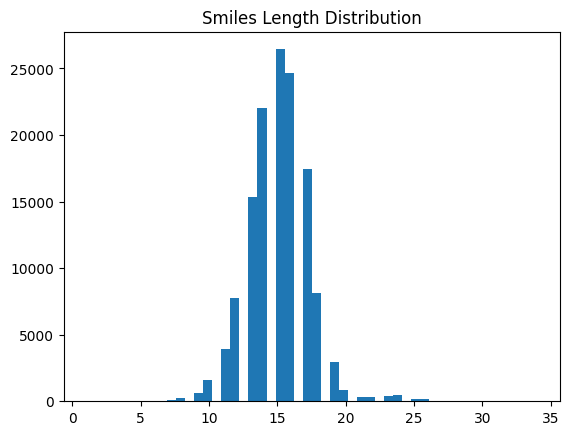

In [30]:
#this plot shows how frequently different lengths appear

plt.hist(lengths, bins=50)
plt.title("Smiles Length Distribution")
plt.show()

In [17]:
print("Max length:", max(lengths))

Max length: 34


In [ ]:
'''finding maximum length to decide the maximum length for the transformer
 tokenizer as Transformer requires a fixed input length and if the length of
 smiles is greater than the maximum input in Transformer then the smiles
 would be cut (truncated)'''

In [20]:
tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")

config.json:   0%|          | 0.00/501 [00:00<?, ?B/s]

c:\Users\Diya\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Diya\.cache\huggingface\hub\models--seyonec--ChemBERTa-zinc-base-v1. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/166 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [21]:
#coverting smiles into token IDs
'''Transformers require all sequences to have the same length so they must 
be padded to equal size (padding=True)'''

encodings = tokenizer(
    smiles_list,
    padding=True,
    truncation=True,          #smiles > max length , cut it
    max_length=64,
    return_tensors="pt"
)

print(encodings)

{'input_ids': tensor([[ 0, 39,  2,  ...,  1,  1,  1],
        [ 0, 39,  7,  ...,  1,  1,  1],
        [ 0, 39,  7,  ...,  1,  1,  1],
        ...,
        [ 0, 82, 21,  ...,  1,  1,  1],
        [ 0, 82, 21,  ...,  1,  1,  1],
        [ 0, 82, 21,  ...,  1,  1,  1]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]])}


In [23]:
'''input_ids contain the numerical tokens representing smiles and 
attetion_mask tells transformer which tokens are real and which are padded'''

input_ids = encodings["input_ids"]
attention_mask = encodings["attention_mask"]    #1 --> real token
                                                #0 --> padded token
print(input_ids)
print(attention_mask)
                                             

tensor([[ 0, 39,  2,  ...,  1,  1,  1],
        [ 0, 39,  7,  ...,  1,  1,  1],
        [ 0, 39,  7,  ...,  1,  1,  1],
        ...,
        [ 0, 82, 21,  ...,  1,  1,  1],
        [ 0, 82, 21,  ...,  1,  1,  1],
        [ 0, 82, 21,  ...,  1,  1,  1]])
tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]])


In [26]:
print(df[target_cols].dtypes)

E1-CC2       float64
E2-CC2       float64
f1-CC2       float64
f2-CC2       float64
E1-PBE0      float64
E2-PBE0      float64
f1-PBE0      float64
f2-PBE0      float64
E1-PBE0.1    float64
E2-PBE0.1    float64
f1-PBE0.1    float64
f2-PBE0.1    float64
E1-CAM       float64
E2-CAM       float64
f1-CAM       float64
f2-CAM       float64
mol_id        object
A            float64
B            float64
C            float64
mu           float64
alpha        float64
homo         float64
lumo         float64
gap          float64
r2           float64
zpve         float64
u0           float64
u298         float64
h298         float64
g298         float64
cv           float64
u0_atom      float64
u298_atom    float64
h298_atom    float64
g298_atom    float64
dtype: object


In [ ]:
df[target_cols] = df[target_cols].apply(pd.to_numeric, errors='coerce')
df[target_cols] = df[target_cols].fillna(0)
targets = df[target_cols].values
print(targets.dtype)

In [31]:
'''Converting targets to tensors because PyTorch neural networks require
tensors as inputs to compute predictions and calculate loss during training.'''

targets = torch.tensor(targets, dtype=torch.float64)
print(targets)

tensor([[ 4.3295e-01,  4.3296e-01,  2.4973e-01,  ..., -3.9864e+02,
         -4.0101e+02, -3.7247e+02],
        [ 3.5863e-01,  3.5863e-01,  0.0000e+00,  ..., -3.8724e+02,
         -3.8902e+02, -3.6580e+02],
        [ 2.7339e-01,  2.8575e-01,  0.0000e+00,  ..., -6.7398e+02,
         -6.7754e+02, -6.3135e+02],
        ...,
        [ 1.6981e-01,  2.2442e-01,  1.1826e-01,  ..., -8.2659e+02,
         -8.3073e+02, -7.6631e+02],
        [ 1.9336e-01,  1.9715e-01,  3.2849e-02,  ..., -7.6818e+02,
         -7.7232e+02, -7.0715e+02],
        [ 2.1345e-01,  2.3180e-01,  7.1635e-03,  ..., -4.3002e+02,
         -4.3239e+02, -3.9692e+02]], dtype=torch.float64)
